# Exploratory Data Analysis (EDA) Project**Dataset:** Titanic Passenger Data (cleaned in Task 1)**Goal:** Explore the dataset statistically and visually to uncover patterns, correlations, and key factors influencing survival.

## 1. Load the Data

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsdf = pd.read_csv('titanic_cleaned.csv')df.shape

(363, 12)

## 2. Statistical Summary

In [1]:
df.describe(include='all')

        PassengerId    Survived      Pclass  ...        Fare    Cabin  Embarkedcount    363.000000  363.000000  363.000000  ...  363.000000      363       363unique          NaN         NaN         NaN  ...         NaN       44         3top             NaN         NaN         NaN  ...         NaN  Unknown         Sfreq            NaN         NaN         NaN  ...         NaN      316       247mean    1096.900826    0.338843    2.429752  ...   18.251274      NaN       NaNstd      120.849644    0.473970    0.752452  ...   14.350374      NaN       NaNmin      892.000000    0.000000    1.000000  ...    0.000000      NaN       NaN25%      993.500000    0.000000    2.000000  ...    7.854200      NaN       NaN50%     1096.000000    0.000000    3.000000  ...   13.000000      NaN       NaN75%     1200.000000    1.000000    3.000000  ...   26.000000      NaN       NaNmax     1309.000000    1.000000    3.000000  ...   65.000000      NaN       NaN

**Finding:** About 34% of passengers in this dataset survived. Fare has a wide range (0 to 65 after outlier removal), and `Cabin` is mostly 'Unknown' (316 of 363 rows).

## 3. Survival Rate by Passenger Class

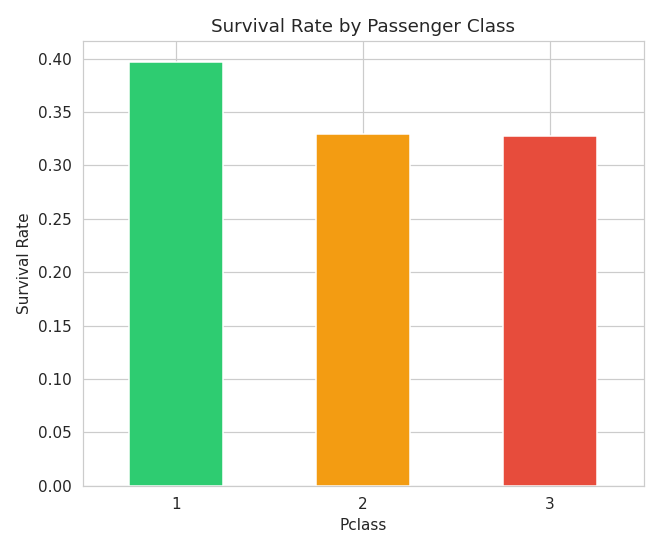

In [1]:
surv_by_class = df.groupby('Pclass')['Survived'].mean()surv_by_class.plot(kind='bar', color=['#2ecc71','#f39c12','#e74c3c'], figsize=(6,5))plt.ylabel('Survival Rate')plt.title('Survival Rate by Passenger Class')plt.xticks(rotation=0)plt.show()surv_by_class

**Insight:** 1st class passengers had a slightly higher survival rate (~40%) than 2nd and 3rd class (~33%) in this particular sample.

## 4. Survival Rate by Gender

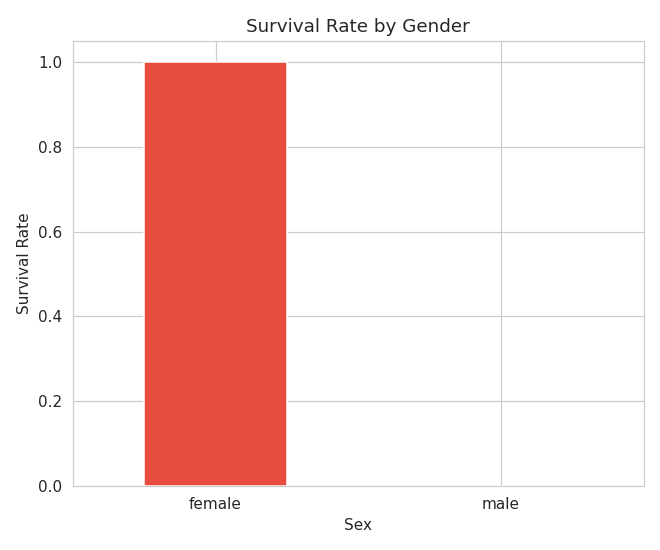

In [1]:
surv_by_sex = df.groupby('Sex')['Survived'].mean()surv_by_sex.plot(kind='bar', color=['#e74c3c','#3498db'], figsize=(6,5))plt.ylabel('Survival Rate')plt.title('Survival Rate by Gender')plt.xticks(rotation=0)plt.show()surv_by_sex

**Insight:** Gender is by far the strongest pattern in this data — female passengers survived at a dramatically higher rate than male passengers, echoing the 'women and children first' policy.

## 5. Age vs Fare, Colored by Survival

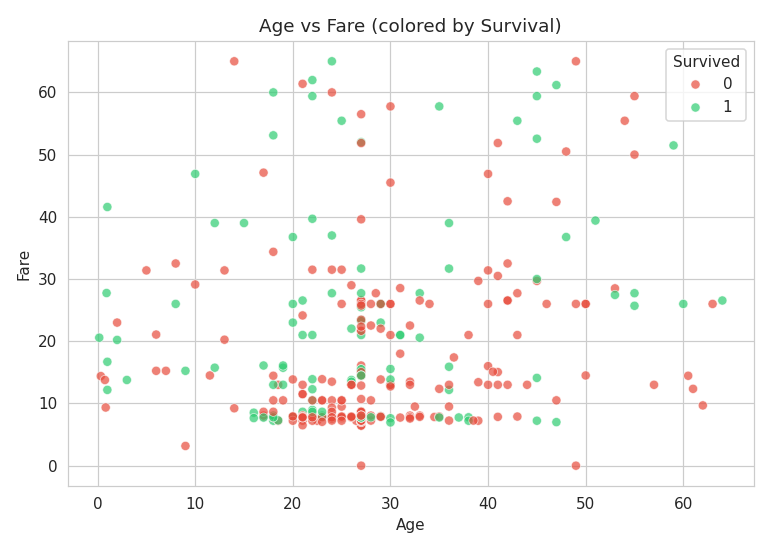

In [1]:
plt.figure(figsize=(7,5))sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette=['#e74c3c','#2ecc71'], alpha=0.7)plt.title('Age vs Fare (colored by Survival)')plt.show()

**Insight:** Survivors (green) are scattered across ages but tend to cluster at slightly higher fares, reinforcing that wealthier passengers had better survival odds.

## 6. Correlation Analysis

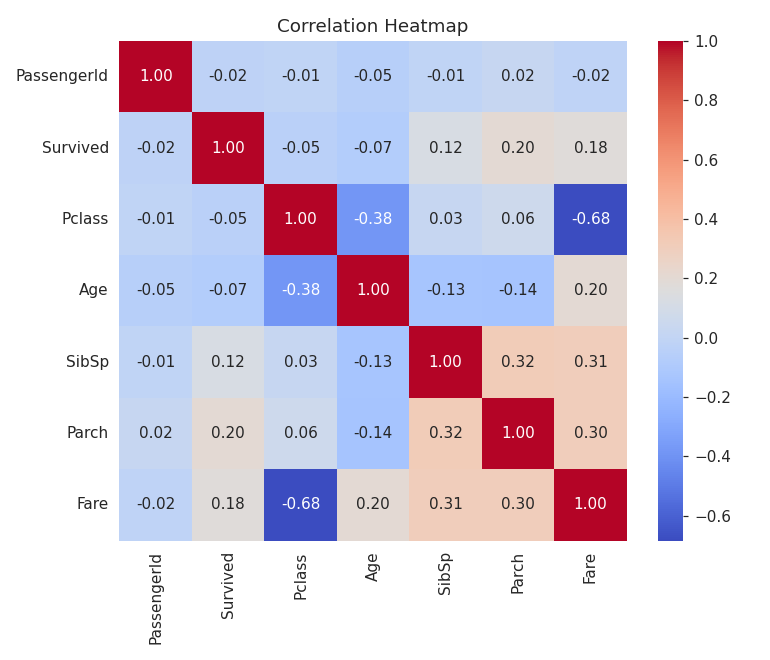

In [1]:
corr = df.select_dtypes(include=[np.number]).corr()plt.figure(figsize=(7,6))sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')plt.title('Correlation Heatmap')plt.show()corr['Survived'].sort_values(ascending=False)

**Insight:** `Parch` (parents/children aboard) and `Fare` show the strongest positive correlation with survival, while `Age` and `Pclass` correlate slightly negatively — larger family units and higher fares were mildly protective.

## 7. Engineered Feature: Family Size

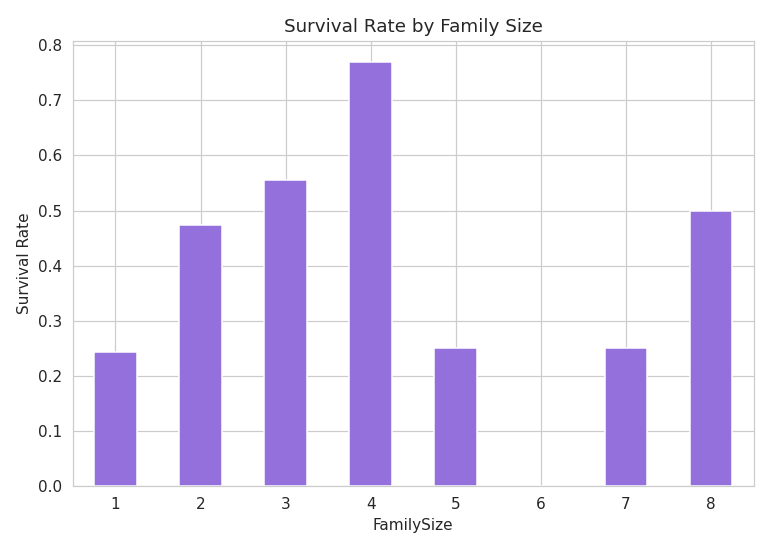

In [1]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1surv_by_family = df.groupby('FamilySize')['Survived'].mean()surv_by_family.plot(kind='bar', color='mediumpurple', figsize=(7,5))plt.ylabel('Survival Rate')plt.title('Survival Rate by Family Size')plt.xticks(rotation=0)plt.show()surv_by_family

**Insight:** Passengers traveling with a small family (2-4 members) had a noticeably higher survival rate than those traveling completely alone or in very large groups (5+), who may have struggled to stay together during evacuation.

## 8. Survival by Port of Embarkation

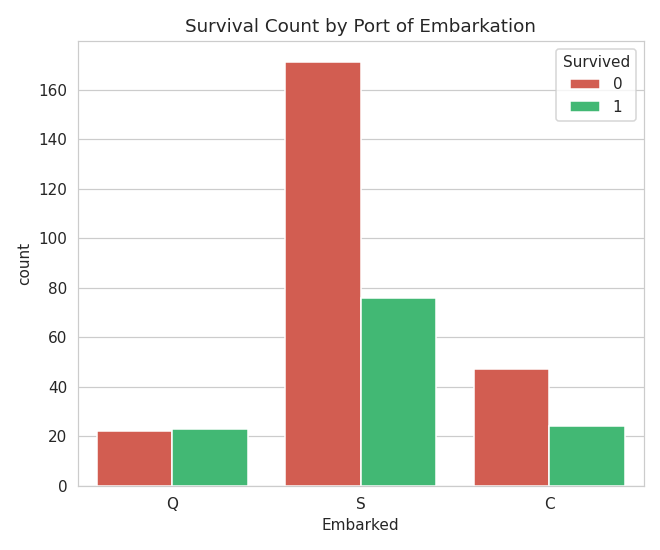

In [1]:
plt.figure(figsize=(6,5))sns.countplot(x='Embarked', hue='Survived', data=df, palette=['#e74c3c','#2ecc71'])plt.title('Survival Count by Port of Embarkation')plt.show()

**Insight:** Most passengers embarked from Southampton (S). Port of embarkation shows only a mild relationship with survival compared to gender and class.

## 9. Summary / Key Findings1. **Gender** is the single strongest factor in survival — this pattern dominates every other variable.2. **Passenger class and fare** show a mild positive relationship with survival — higher class / higher fare passengers had a slight edge.3. **Family size** matters — small families (2-4 members) survived more often than solo travelers or very large families.4. **Age** has only a weak relationship with survival in this sample.5. **Port of embarkation** has minimal predictive value on its own.**Overall conclusion:** Social factors (gender, class, family structure) were more influential in survival outcomes than purely personal factors like age — consistent with the historical maritime evacuation protocol of the era.**Tools used:** Python, Pandas, Matplotlib, Seaborn